![BSC AI Factory — Homomorphic Encryption — Module 6](assets/headers/homomorphic-encryption.jpg)

# 05. Homomorphic encryption

**Topic: Module 6 · Walkthrough: Module 8, slide 7**

Train a small decision tree, compile it for encrypted computation, and pass a patient through separate client/server APIs. Compare decrypted predictions with the same quantized model in clear mode and measure each stage.

**Code co-created by:** Ülkü Tuncer Küçüktaş, Simge Danışoğlu, Tolga Turan, Gizem Acer.


## Setup

Use a **separate Python 3.11 environment** for this notebook. A Colab runtime must also use Python 3.11
for these exact pins. The pinned Concrete ML and Flower versions require incompatible Protobuf
versions. Do not install both into the same kernel. macOS and Linux are supported; Windows needs WSL.

Run the setup cell first. If it installs packages, restart the kernel/runtime once and choose **Run All**.
The main experiment performs real encrypted execution; it does not substitute simulation results.
Compilation and key generation can take several minutes. The default encrypted batch is three patients.


In [1]:
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        "This pinned course pack requires Python 3.11. "
        "Select a Python 3.11 kernel before installing packages."
    )

REQUIRED = {
    "numpy": "1.26.4",
    "pandas": "2.0.3",
    "scipy": "1.13.1",
    "scikit-learn": "1.5.0",
    "matplotlib": "3.9.4",
    "concrete-ml": "1.9.0",
}


def installed_version(package):
    try:
        return version(package)
    except PackageNotFoundError:
        return None


packages_to_install = [
    f"{package}=={required_version}"
    for package, required_version in REQUIRED.items()
    if installed_version(package) != required_version
]
if packages_to_install:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *packages_to_install]
    )
    raise RuntimeError("Setup finished. Restart the kernel/runtime, then Run All.")

print("Dependencies ready:", {package: version(package) for package in REQUIRED})


Dependencies ready: {'numpy': '1.26.4', 'pandas': '2.0.3', 'scipy': '1.13.1', 'scikit-learn': '1.5.0', 'matplotlib': '3.9.4', 'concrete-ml': '1.9.0'}


In [2]:
import hashlib
import json
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split

import platform
import shutil
import tempfile
import time

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from concrete.ml.sklearn import DecisionTreeClassifier as FHEDecisionTreeClassifier
from concrete.ml.deployment import FHEModelDev, FHEModelClient, FHEModelServer

NAVY, BLUE, TEAL, GOLD, RED = "#1C3076", "#3457A6", "#168A88", "#C58A00", "#B53B4A"
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
    }
)

ARTIFACT_DIR = Path("generated/05_homomorphic_encryption")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

HEART_HASHES = {
    "processed.cleveland.data": "a74b7efa387bc9d108d7d0115d831fe9b414b29ae7124f331b622b4efa0427c8",
    "processed.hungarian.data": "d1ad108f785768cd3d7e82dc522e6f5a61eea93cccfb3a46ee8076f73fc3d796",
    "processed.switzerland.data": "834a405ccf5b66ab4056bb77794adc8df0b7125186454c0a1d002d33c6c3b314",
    "processed.va.data": "e7c93d8d0d2acdadfa4c5e8de768e2191e7f618b952e29623f1f0d5949ff6b8f",
}
HEART_COLUMNS = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num",
]


def read_hospital(filename):
    """Read the checked course copy, downloading it only when it is missing."""
    data_path = DATA_DIR / filename
    expected_hash = HEART_HASHES[filename]
    if not data_path.exists():
        base_url = (
            "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/"
        )
        downloaded_data = urllib.request.urlopen(base_url + filename, timeout=60).read()
        if hashlib.sha256(downloaded_data).hexdigest() != expected_hash:
            raise ValueError("Downloaded data differs from the checked course copy.")
        data_path.write_bytes(downloaded_data)

    assert hashlib.sha256(data_path.read_bytes()).hexdigest() == expected_hash
    return pd.read_csv(data_path, names=HEART_COLUMNS, na_values="?")


## 1. Prepare the training and test data

Use the Cleveland subset from the original example. Six records with missing values are dropped.
The remaining 297 rows are split before training. The binary target is `num > 0`. The exercise
predicts the historical dataset label; it is not a diagnostic service.


In [3]:
hospital_data = (
    read_hospital("processed.cleveland.data").dropna().reset_index(drop=True)
)
FEATURES = HEART_COLUMNS[:-1]
features = hospital_data[FEATURES].to_numpy(dtype=np.float64)
labels = (hospital_data.num > 0).astype(int).to_numpy()
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, test_size=0.2, random_state=0, stratify=labels
)
MAX_DEPTH, N_BITS, N_ENCRYPTED = 3, 6, 3
print("Train:", train_features.shape, "Test:", test_features.shape)


Train: (237, 13) Test: (60, 13)


## 2. Fit a float baseline and a quantized tree

The float tree is a reference. Concrete ML trains and quantizes a tree of the same depth. Quantization
can change its predictions, so the float tree is **not** the equality reference for encryption.
Encryption agreement is checked against the quantized tree's own clear-mode output.


,model,test_accuracy
0,Float baseline,0.783333
1,Quantized / clear mode,0.766667


Float vs quantized agreement: 0.9833333333333333


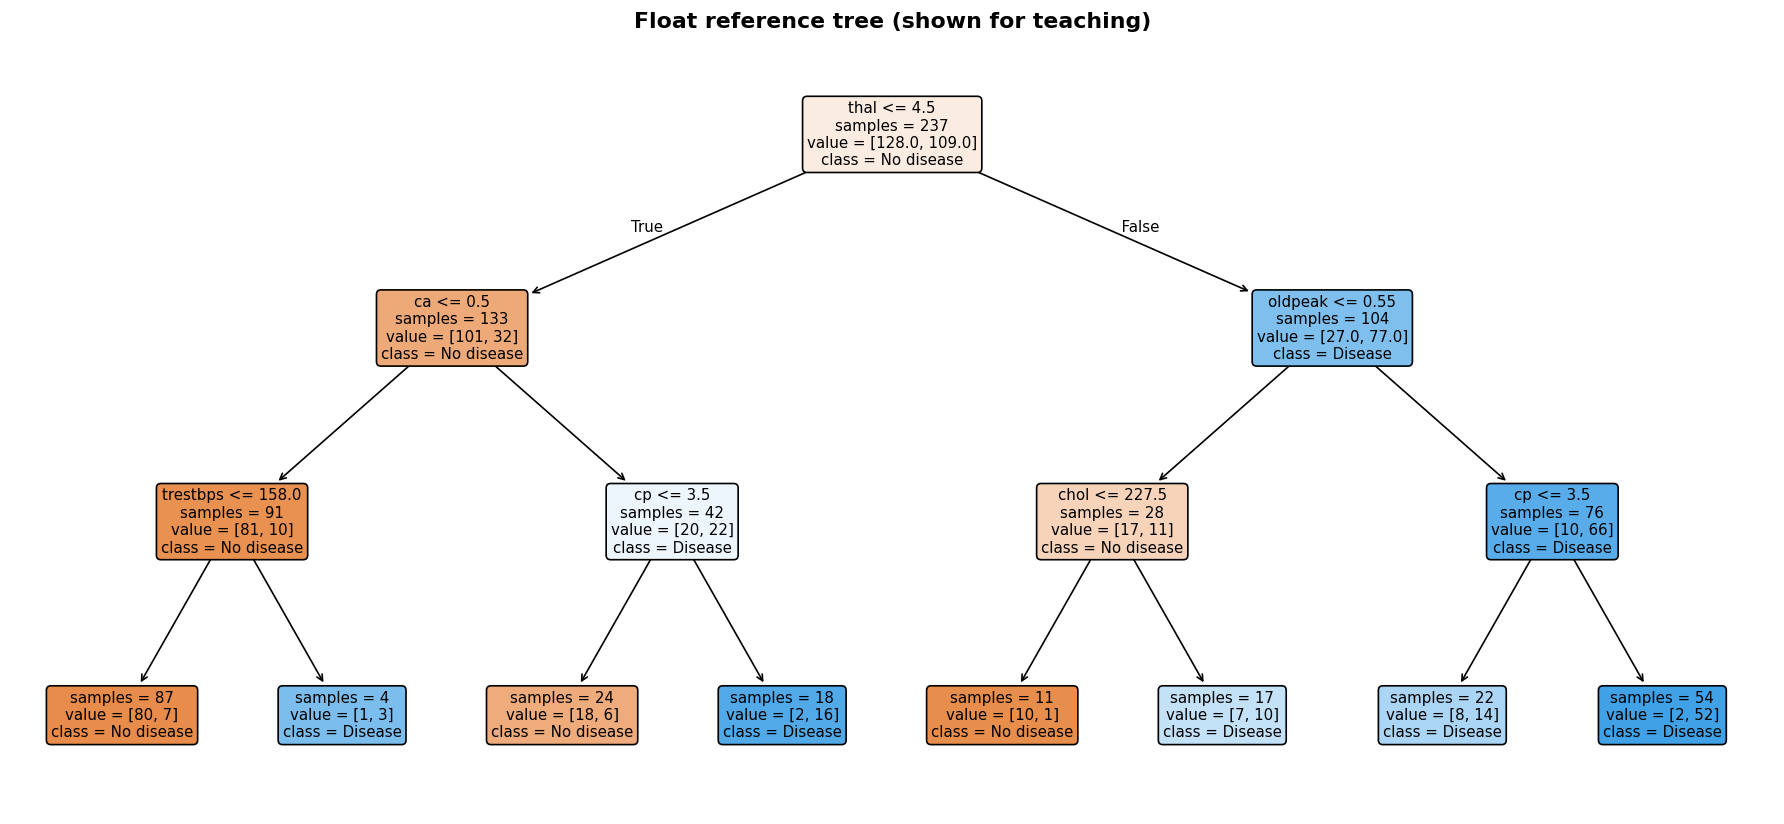

In [4]:
float_tree = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=0)
float_tree.fit(train_features, train_labels)
quantized_tree = FHEDecisionTreeClassifier(
    max_depth=MAX_DEPTH, n_bits=N_BITS, random_state=0
)
quantized_tree.fit(train_features, train_labels)

float_predictions = float_tree.predict(test_features)
quantized_predictions = quantized_tree.predict(test_features, fhe="disable")
model_summary = pd.DataFrame(
    {
        "model": ["Float baseline", "Quantized / clear mode"],
        "test_accuracy": [
            accuracy_score(test_labels, float_predictions),
            accuracy_score(test_labels, quantized_predictions),
        ],
    }
)
display(model_summary)
print(
    "Float vs quantized agreement:", np.mean(float_predictions == quantized_predictions)
)

figure, axis = plt.subplots(figsize=(15, 7))
plot_tree(
    float_tree,
    feature_names=FEATURES,
    class_names=["No disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,
    ax=axis,
)
axis.set_title("Float reference tree (shown for teaching)")
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "reference_tree.png", bbox_inches="tight")
plt.show()


## 3. Compile and separate the client/server artifacts

The server gets the compiled model. The clinic receives encryption specifications and preprocessing
metadata, not the trained decision tree. The clinic generates its secret key locally. Here the three
roles live in separate directories on one machine so their inputs are visible; this is a deployment
API demonstration, not an actual cloud deployment or a hardened isolation boundary.

The notebook author can inspect the training model for teaching. A deployed clinic would receive
only the client package. Output predictions and preprocessing metadata still reveal information;
FHE alone is not a general model-extraction defense or a proof that a server computed honestly.


In [5]:
def create_client_server(model, role_root, server_folder="server"):
    """Give the clinic and server their respective deployment packages."""
    developer_dir = role_root / "developer"
    clinic_dir = role_root / "clinic"
    server_dir = role_root / server_folder
    for directory in [developer_dir, clinic_dir, server_dir]:
        directory.mkdir()

    FHEModelDev(path_dir=str(developer_dir), model=model).save()
    shutil.copy2(developer_dir / "client.zip", clinic_dir / "client.zip")
    shutil.copy2(developer_dir / "server.zip", server_dir / "server.zip")
    clinic_client = FHEModelClient(
        path_dir=str(clinic_dir), key_dir=str(clinic_dir / "keys")
    )
    cloud_server = FHEModelServer(path_dir=str(server_dir))
    cloud_server.load()
    return clinic_client, cloud_server, clinic_dir, server_dir


started = time.perf_counter()
quantized_tree.compile(train_features, p_error=1e-6)
compile_seconds = time.perf_counter() - started
print(f"Compilation: {compile_seconds:.2f} s")

# Fresh temporary role directories and keys; secret keys are never packaged with the course.
role_workspace = tempfile.TemporaryDirectory(prefix="course-fhe-")
role_root = Path(role_workspace.name)
clinic_client, cloud_server, clinic_dir, server_dir = create_client_server(
    quantized_tree, role_root
)
started = time.perf_counter()
evaluation_keys = clinic_client.get_serialized_evaluation_keys()
keygen_seconds = time.perf_counter() - started
assert {path.name for path in server_dir.iterdir()} == {"server.zip"}
assert not (clinic_dir / "server.zip").exists()
print(
    f"Client key setup: {keygen_seconds:.2f} s; "
    f"public evaluation keys: {len(evaluation_keys):,} bytes"
)


Compilation: 0.98 s


Client key setup: 0.66 s; public evaluation keys: 53,887,760 bytes


KeySetCache: miss, regenerating /var/folders/gd/v7_c096d01bfs1q20hc3t8q80000gn/T/course-fhe-kdufg9_g/clinic/keys/18194400113098654531


## 4. Encrypt at the clinic, compute at the server, decrypt at the clinic

Only serialized ciphertext and evaluation keys are passed to `cloud_server.run`. The secret key stays in
the client object. Client/server classifiers return class probabilities after decryption; the clinic
maps the largest probability to the public class labels. We time encryption, server computation and
decryption separately, excluding one-time compilation and key setup.


In [6]:
assert 1 <= N_ENCRYPTED <= len(test_features)
PUBLIC_CLASSES = np.array([0, 1])
patient_results = []
for patient_index in range(N_ENCRYPTED):
    patient = test_features[patient_index : patient_index + 1]

    # 1. The clinic encrypts one patient's feature row.
    started = time.perf_counter()
    encrypted_input = clinic_client.quantize_encrypt_serialize(patient)
    encrypt_seconds = time.perf_counter() - started

    # 2. The server receives ciphertext and evaluation keys, not the secret key.
    started = time.perf_counter()
    encrypted_output = cloud_server.run(encrypted_input, evaluation_keys)
    server_seconds = time.perf_counter() - started

    # 3. The clinic decrypts the probabilities and chooses a class.
    started = time.perf_counter()
    probabilities = clinic_client.deserialize_decrypt_dequantize(encrypted_output)
    predicted_class_index = np.argmax(probabilities, axis=1)[0]
    encrypted_prediction = int(PUBLIC_CLASSES[predicted_class_index])
    decrypt_seconds = time.perf_counter() - started

    # Compare with the same quantized tree in clear mode, not the float baseline.
    started = time.perf_counter()
    clear_prediction = int(quantized_tree.predict(patient, fhe="disable")[0])
    clear_seconds = time.perf_counter() - started
    assert (
        encrypted_prediction == clear_prediction
    ), "Encrypted and quantized-clear predictions differ."
    patient_results.append(
        {
            "test_row": patient_index,
            "true_label": int(test_labels[patient_index]),
            "quantized_clear": clear_prediction,
            "encrypted_prediction": encrypted_prediction,
            "encrypt_s": encrypt_seconds,
            "server_s": server_seconds,
            "decrypt_s": decrypt_seconds,
            "roundtrip_s": encrypt_seconds + server_seconds + decrypt_seconds,
            "clear_s": clear_seconds,
        }
    )

results = pd.DataFrame(patient_results)
display(results.round(5))
print(f"Encrypted/quantized-clear agreement: {N_ENCRYPTED}/{N_ENCRYPTED}")
print(
    "Accuracy on this small batch:",
    accuracy_score(results.true_label, results.encrypted_prediction),
)


,test_row,true_label,quantized_clear,encrypted_prediction,encrypt_s,server_s,decrypt_s,roundtrip_s,clear_s
0,0,1,0,0,0.00363,1.30987,0.00106,1.31456,0.00038
1,1,1,1,1,0.00176,0.76590,0.00079,0.76846,0.00038
2,2,1,1,1,0.00181,0.76462,0.00084,0.76727,0.00033


Encrypted/quantized-clear agreement: 3/3
Accuracy on this small batch: 0.6666666666666666


## 5. Inspect the cost

The comparison above tests the encryption path against exactly the same quantized model. It does
not establish agreement with the float baseline or accuracy on future patients. The compiler uses
a nonzero cryptographic error target (`p_error`); observed agreement is a test result, not an absolute
no-error guarantee. Timing is specific to this machine, model and batch and excludes network latency.


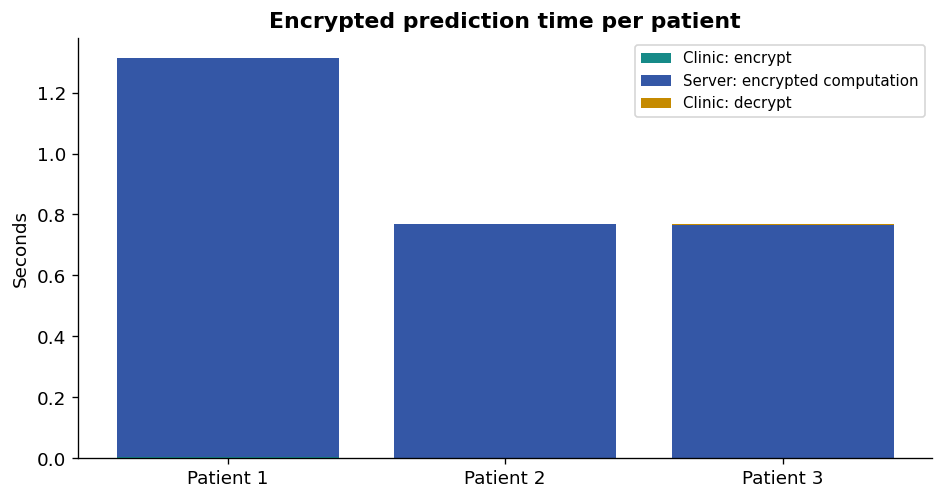

Checks passed. Temporary deployment files and key cache removed.


In [7]:
figure, axis = plt.subplots(figsize=(8, 4.3))
patient_positions = np.arange(N_ENCRYPTED)
stacked_seconds = np.zeros(N_ENCRYPTED)
stages = [
    ("encrypt_s", "Clinic: encrypt", TEAL),
    ("server_s", "Server: encrypted computation", BLUE),
    ("decrypt_s", "Clinic: decrypt", GOLD),
]
for column, stage_label, color in stages:
    axis.bar(
        patient_positions,
        results[column],
        bottom=stacked_seconds,
        label=stage_label,
        color=color,
    )
    stacked_seconds += results[column]
axis.set(
    xticks=patient_positions,
    xticklabels=[f"Patient {index + 1}" for index in patient_positions],
    ylabel="Seconds",
    title="Encrypted prediction time per patient",
)
axis.legend(fontsize=9)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "encrypted_prediction_timing.png", bbox_inches="tight")
plt.show()
results.to_csv(ARTIFACT_DIR / "encrypted_results.csv", index=False)
model_summary.to_csv(ARTIFACT_DIR / "model_accuracy.csv", index=False)

summary = {
    "real_encrypted_execution": True,
    "patients_checked": N_ENCRYPTED,
    "agreement_with_quantized_clear": int(
        (results.quantized_clear == results.encrypted_prediction).sum()
    ),
    "compile_seconds": compile_seconds,
    "keygen_seconds": keygen_seconds,
    "mean_roundtrip_seconds": float(results.roundtrip_s.mean()),
    "python": platform.python_version(),
    "machine": platform.machine(),
    "system": platform.system(),
    "concrete_ml": version("concrete-ml"),
    "n_bits": N_BITS,
    "max_depth": MAX_DEPTH,
}
(ARTIFACT_DIR / "checks.json").write_text(json.dumps(summary, indent=2))
role_workspace.cleanup()
print("Checks passed. Temporary deployment files and key cache removed.")


## Experiments

1. Change `N_BITS` to 5; rerun from model training and compare accuracy, compile time and inference time.
2. Change `MAX_DEPTH` to 2 or 4 and repeat. Do not assume more depth always gives better test accuracy.
3. Increase `N_ENCRYPTED` for a broader agreement check. Keep setup time separate from per-patient time.

References: [Concrete ML deployment](https://docs.zama.org/concrete-ml/guides/client_server),
[installation](https://docs.zama.org/concrete-ml/get-started/pip_installing),
[UCI Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease).


## Optional extension: encrypted classifier comparison

Adapted from sections 7–11 of `Homomorphic_Encryption_Classifier_Comparison-2.ipynb`.
Compare the decision tree with logistic regression, measuring predictive accuracy,
quantization effects, compilation, key setup and encrypted inference separately.

| HE family | Arithmetic | Suitable examples |
| --- | --- | --- |
| BFV/BGV | Exact integers modulo a chosen plaintext modulus | Bounded integer sums and products; encoding must account for wraparound |
| CKKS | Approximate real/complex arithmetic | Packed linear algebra with an explicit numerical error tolerance |
| TFHE-style circuits | Integer/bit operations and programmable bootstrapping | Comparisons and lookup-based quantized models |

This table describes different encryption families. The code below compares two classifiers
in Concrete ML; it does not benchmark BFV/BGV against CKKS or TFHE. Both models are trained
on clear data, and inference runs on encrypted inputs.

Set `RUN_CLASSIFIER_EXTENSION = False` to skip this comparison. No extra packages are required.


In [8]:
RUN_CLASSIFIER_EXTENSION = True
EXT_LR_BITS = 8

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from concrete.ml.sklearn import LogisticRegression as FHELogisticRegression


def encrypted_benchmark(model, test_features, true_labels):
    """Time the same client/server protocol for each classifier and patient."""
    patient_results = []
    with tempfile.TemporaryDirectory(prefix="course-fhe-comparison-") as role_path:
        local_client, remote_server, _, server_dir = create_client_server(
            model, Path(role_path), server_folder="cloud"
        )
        started = time.perf_counter()
        public_evaluation_keys = local_client.get_serialized_evaluation_keys()
        key_setup_seconds = time.perf_counter() - started

        for patient_index, feature_row in enumerate(test_features):
            patient = feature_row.reshape(1, -1)
            started = time.perf_counter()
            clear_prediction = int(model.predict(patient, fhe="disable")[0])
            clear_seconds = time.perf_counter() - started

            started = time.perf_counter()
            encrypted_input = local_client.quantize_encrypt_serialize(patient)
            encrypt_seconds = time.perf_counter() - started

            started = time.perf_counter()
            encrypted_output = remote_server.run(
                encrypted_input, public_evaluation_keys
            )
            server_seconds = time.perf_counter() - started

            started = time.perf_counter()
            probabilities = local_client.deserialize_decrypt_dequantize(
                encrypted_output
            )
            predicted_class_index = np.argmax(probabilities, axis=1)[0]
            encrypted_prediction = int(PUBLIC_CLASSES[predicted_class_index])
            decrypt_seconds = time.perf_counter() - started
            assert (
                encrypted_prediction == clear_prediction
            ), "FHE must match this model's quantized-clear result."
            patient_results.append(
                {
                    "test_row": patient_index,
                    "true_label": int(true_labels[patient_index]),
                    "clear_prediction": clear_prediction,
                    "encrypted_prediction": encrypted_prediction,
                    "clear_s": clear_seconds,
                    "encrypt_s": encrypt_seconds,
                    "server_s": server_seconds,
                    "decrypt_s": decrypt_seconds,
                    "roundtrip_s": encrypt_seconds + server_seconds + decrypt_seconds,
                }
            )
        assert {path.name for path in server_dir.iterdir()} == {"server.zip"}

    return pd.DataFrame(patient_results), key_setup_seconds


def classifier_summary(
    name,
    float_model,
    quantized_model,
    full_test_features,
    full_test_labels,
    encrypted_results,
    compilation_seconds,
    key_setup_seconds,
):
    """Keep full-test model quality separate from encrypted-subset checks."""
    float_predictions = float_model.predict(full_test_features)
    quantized_predictions = quantized_model.predict(full_test_features, fhe="disable")
    agreement = (
        encrypted_results.clear_prediction == encrypted_results.encrypted_prediction
    )
    return {
        "classifier": name,
        "float_accuracy_full_test": accuracy_score(full_test_labels, float_predictions),
        "quantized_accuracy_full_test": accuracy_score(
            full_test_labels, quantized_predictions
        ),
        "encrypted_batch_size": len(encrypted_results),
        "encrypted_accuracy_subset": accuracy_score(
            encrypted_results.true_label, encrypted_results.encrypted_prediction
        ),
        "encrypted_clear_agreement": float(agreement.mean()),
        "compile_s": compilation_seconds,
        "key_setup_s": key_setup_seconds,
        "clear_ms_per_patient": 1000 * encrypted_results.clear_s.mean(),
        "encrypted_roundtrip_s_per_patient": encrypted_results.roundtrip_s.mean(),
    }


KeySetCache: miss, regenerating /var/folders/gd/v7_c096d01bfs1q20hc3t8q80000gn/T/course-fhe-comparison-ste0tnzv/clinic/keys/18194400113098654531


KeySetCache: miss, regenerating /var/folders/gd/v7_c096d01bfs1q20hc3t8q80000gn/T/course-fhe-comparison-dq_mwyh8/clinic/keys/17586329962004342717


,float_accuracy_full_test,quantized_accuracy_full_test,encrypted_batch_size,encrypted_accuracy_subset,encrypted_clear_agreement,compile_s,key_setup_s,clear_ms_per_patient,encrypted_roundtrip_s_per_patient
classifier,,,,,,,,,
Decision tree,0.78333,0.76667,3,0.66667,1.0,0.98253,0.60873,0.29711,0.75862
Logistic regression,0.85000,0.85000,3,0.66667,1.0,0.10330,0.00049,0.14199,0.07434


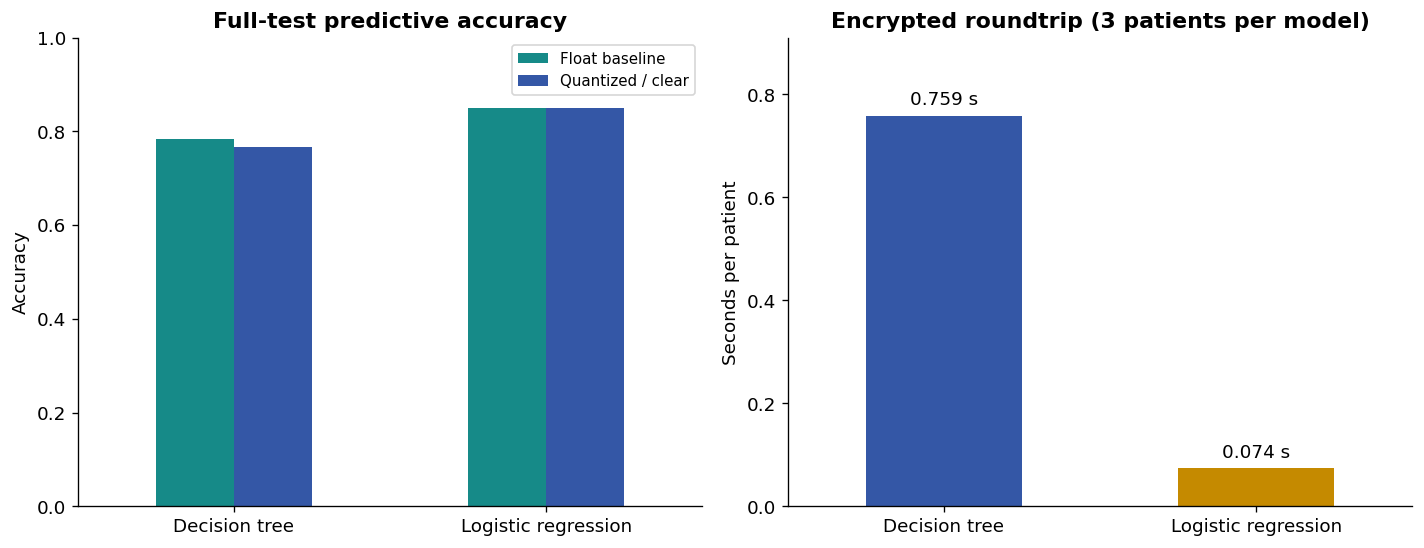

Extension checks passed; main tree predictions are unchanged and temporary keys removed.


In [9]:
if RUN_CLASSIFIER_EXTENSION:
    classifier_dir = ARTIFACT_DIR / "classifier_extension"
    classifier_dir.mkdir(exist_ok=True)
    core_predictions_before = quantized_tree.predict(
        test_features, fhe="disable"
    ).copy()

    # Fit preprocessing on the same training split; never fit it on test patients.
    logistic_scaler = StandardScaler().fit(train_features)
    logistic_train_features = logistic_scaler.transform(train_features)
    logistic_test_features = logistic_scaler.transform(test_features)
    float_logistic = LogisticRegression(max_iter=2000, random_state=0)
    float_logistic.fit(logistic_train_features, train_labels)
    quantized_logistic = FHELogisticRegression(
        n_bits=EXT_LR_BITS, max_iter=2000, random_state=0
    )
    quantized_logistic.fit(logistic_train_features, train_labels)

    started = time.perf_counter()
    quantized_logistic.compile(logistic_train_features, p_error=1e-6)
    logistic_compile_seconds = time.perf_counter() - started

    # Both models receive the same held-out patients, in the same order.
    benchmark_size = N_ENCRYPTED
    benchmark_labels = test_labels[:benchmark_size]
    tree_results, tree_key_seconds = encrypted_benchmark(
        quantized_tree, test_features[:benchmark_size], benchmark_labels
    )
    logistic_results, logistic_key_seconds = encrypted_benchmark(
        quantized_logistic, logistic_test_features[:benchmark_size], benchmark_labels
    )
    classifier_comparison = pd.DataFrame(
        [
            classifier_summary(
                "Decision tree",
                float_tree,
                quantized_tree,
                test_features,
                test_labels,
                tree_results,
                compile_seconds,
                tree_key_seconds,
            ),
            classifier_summary(
                "Logistic regression",
                float_logistic,
                quantized_logistic,
                logistic_test_features,
                test_labels,
                logistic_results,
                logistic_compile_seconds,
                logistic_key_seconds,
            ),
        ]
    ).set_index("classifier")
    display(classifier_comparison.round(5))

    figure, (accuracy_axis, timing_axis) = plt.subplots(1, 2, figsize=(12, 4.7))
    accuracy_columns = ["float_accuracy_full_test", "quantized_accuracy_full_test"]
    accuracy_labels = {
        "float_accuracy_full_test": "Float baseline",
        "quantized_accuracy_full_test": "Quantized / clear",
    }
    classifier_comparison[accuracy_columns].rename(columns=accuracy_labels).plot.bar(
        ax=accuracy_axis, rot=0, ylim=(0, 1), color=[TEAL, BLUE]
    )
    accuracy_axis.set(
        title="Full-test predictive accuracy", ylabel="Accuracy", xlabel=""
    )
    accuracy_axis.legend(fontsize=9)

    roundtrip_times = classifier_comparison.encrypted_roundtrip_s_per_patient
    roundtrip_times.plot.bar(ax=timing_axis, color=[BLUE, GOLD], rot=0)
    timing_axis.set(
        title=f"Encrypted roundtrip ({benchmark_size} patients per model)",
        ylabel="Seconds per patient",
        xlabel="",
        ylim=(0, roundtrip_times.max() * 1.2),
    )
    timing_axis.bar_label(
        timing_axis.containers[0],
        labels=[f"{seconds:.3f} s" for seconds in roundtrip_times],
        padding=4,
    )
    figure.tight_layout()
    figure.savefig(classifier_dir / "classifier_comparison.png", bbox_inches="tight")
    plt.show()

    classifier_comparison.to_csv(classifier_dir / "classifier_comparison.csv")
    tree_results.assign(classifier="Decision tree").to_csv(
        classifier_dir / "tree_per_patient.csv", index=False
    )
    logistic_results.assign(classifier="Logistic regression").to_csv(
        classifier_dir / "logistic_per_patient.csv", index=False
    )
    np.testing.assert_array_equal(
        quantized_tree.predict(test_features, fhe="disable"), core_predictions_before
    )
    assert classifier_comparison.encrypted_clear_agreement.eq(1).all()
    assert tree_results.test_row.tolist() == logistic_results.test_row.tolist()
    classifier_checks = {
        "source": "Homomorphic_Encryption_Classifier_Comparison-2.ipynb",
        "real_encrypted_execution": True,
        "patients_per_classifier": benchmark_size,
        "both_models_match_their_own_quantized_clear_results": True,
        "same_held_out_patient_rows": True,
        "scaler_fit_on_training_only": True,
        "main_tree_predictions_unchanged": True,
        "same_client_server_timing_protocol": True,
        "logistic_regression_n_bits": EXT_LR_BITS,
    }
    (classifier_dir / "checks.json").write_text(json.dumps(classifier_checks, indent=2))
    print(
        "Extension checks passed; main tree predictions are unchanged and temporary keys removed."
    )
else:
    print("Classifier comparison skipped.")


### Read the comparison

Full-test accuracy measures predictive quality. Encrypted agreement compares each classifier
with its own quantized-clear predictions. The small encrypted subset is reported separately
from the full test set.

Both classifiers use the same patient rows, client/server protocol and timing boundaries.
The reported means include the first request. Compilation and key setup are timed separately.
The tree uses six-bit inputs; logistic regression uses eight-bit inputs. Their circuits also
perform different work, so these timings compare the two specified configurations on this
machine. They do not establish a general speed ranking for models or encryption families.
The logistic-regression scaler is fitted on training data only.

Documentation: [Concrete ML linear models](https://docs.zama.org/concrete-ml/built-in-models/linear),
[client/server deployment](https://docs.zama.org/concrete-ml/guides/client_server).
